### Build a Basic Chatbot with LangGraph: Graph API 

Edges

Nodes

State

In [2]:
from typing import Annotated # add contextual meta-data

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq

# llm

llm = ChatGroq(model="openai/gpt-oss-20b")

In [6]:
# node functionality
def chatbot(state: State):
    return {"messages" : [llm.invoke(state["messages"])]}

In [7]:
graph_builder = StateGraph(State)
# add the node
graph_builder.add_node("llm_chatbot", chatbot)
# add edges
graph_builder.add_edge(START, "llm_chatbot")
graph_builder.add_edge("llm_chatbot", END)

## compile the graph
graph = graph_builder.compile()

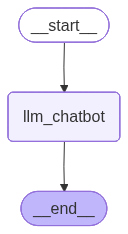

In [8]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
from pprint import pprint

result = graph.invoke(
    {"messages":"Make a 5 line poem on RAG"}
)

for i, msg in enumerate(result["messages"], 1):
    print(f"\n{'='*60}")
    print(f"Message {i}: {type(msg).__name__}")
    print(f"{'='*60}")

    print("Content:")
    print(msg.content)


Message 1: HumanMessage
Content:
Make a 5 line poem on RAG

Message 2: AIMessage
Content:
Red blazes the start, a warning that sparks the fire,  
Amber hums in the middle, a pause to watch the wire,  
Green sighs the finish, a breath of calm and cheer,  
RAG, the silent guide that maps what we hold dear,  
In every pulse it paints the path we steer.


In [10]:
for event in graph.stream({"messages": "Hi, How are you? Reply in two word"}):
    for value in event.values():
        print(value["messages"][-1].content)

Fine, thanks.


### Chatbot with External tools

In [11]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)

tool.invoke("What are the latest advancements in AI? Be brief in your response.")

{'query': 'What are the latest advancements in AI? Be brief in your response.',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://dreamertechnoland.com/latest-advancements-in-artificial-intelligence',
   'title': 'Latest Advancements in AI Technology 2025 - Dreamer Technoland',
   'content': 'What Are the Latest Advancements in AI? · Next gen Large Language Models & Multimodal AI · Emergence of Autonomous and Agentic AI · Embodied AI &',
   'score': 0.752468,
   'raw_content': None},
  {'url': 'https://ai100.stanford.edu/gathering-strength-gathering-storms-one-hundred-year-study-artificial-intelligence-ai100-2021-1/sq2',
   'title': 'SQ2. What are the most important advances in AI?',
   'content': 'The field of AI has made major progress in almost all its standard sub-areas, including vision, speech recognition and generation, natural language processing.',
   'score': 0.60077465,
   'raw_content': None}],
 'response_time': 0.81,
 'request_id':

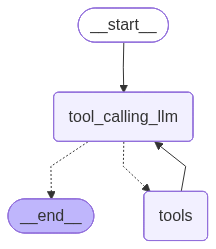

In [12]:
## StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_groq import ChatGroq
from IPython.display import Image, display

# llm

llm = ChatGroq(model="openai/gpt-oss-20b")

# tool 1
from langchain_tavily import TavilySearch
tool = TavilySearch(max_results = 1)

# tool 2 (custom)

def multiply(a: int, b: int) -> int:
    """Multiply a and b
    
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """

    return a * b

tools = [tool, multiply]
llm_with_tools = llm.bind_tools(tools)

# Node definition

class State(TypedDict):
    messages: Annotated[list, add_messages]

def tool_calling_llm(state: State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

### GRAPH

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add the edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", # from tool_calling_llm tool
    # If the latest message from assistant is a tool call -> tools_condiiton routes to tools

    # If the latest message (result) from assistant is not a tool call -> tools_condition roites to END (by default, no need to add it ourselves)
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

# Now we have conditional edges

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [14]:
response = graph.invoke({"messages": "Get me the latest AI news. What's 2 multiplied by 3?"})

In [15]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Get me the latest AI news. What's 2 multiplied by 3?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_0b2319aa-51d8-4ad7-b6b1-2c622642360c)
 Call ID: fc_0b2319aa-51d8-4ad7-b6b1-2c622642360c
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/210511-the-new-language-of-the-ai-world-key-terms-you-need-to-know-in-2024.html", "title": "The New Language of the AI World: Key Terms You Need to Know in 2024 - Zamin.uz", "score": 0.65359193, "published_date": "Fri, 03 Jul 2026 21:23:18 GMT", "content": "## Comments0\n\n…\n\n## Related news\n\nAI Could Not Replace Humans:

In [16]:
response2 = graph.invoke({"messages": "What is 2 multiplied by 3 then by 7? Invoke the multiply tool"})
for m in response2['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3 then by 7? Invoke the multiply tool
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_a234ca4c-1745-4a27-baac-590a2320f089)
 Call ID: fc_a234ca4c-1745-4a27-baac-590a2320f089
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_9fd5dd89-07b8-4182-b090-4f0a78740520)
 Call ID: fc_9fd5dd89-07b8-4182-b090-4f0a78740520
  Args:
    a: 6
    b: 7
================================= Tool Message =================================
Name: multiply

42
================================== Ai Message ==================================

42


## Adding memory in Agentic graph

In [17]:
response = graph.invoke(
    {
        "messages": "Hello! My name is Abdul"
    }
)

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello! My name is Abdul
================================== Ai Message ==================================

Hello Abdul! How can I help you today?


In [18]:
response = graph.invoke(
    {
        "messages": "Do you know my name?"
    }
)

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Do you know my name?
================================== Ai Message ==================================

I don’t have any information about you unless you share it. What would you like me to call you?
